# 04 — Evaluation (Phase 5) & Explainability (Phase 6)

This notebook covers **Phase 5 only** for now — precision@k, recall-per-typology, the headline false-positive-reduction-vs-rules-baseline-at-equal-recall number, PR-AUC/ROC-AUC, and calibration, all via `src/evaluate.py`. Phase 6 (SHAP explainability) will append sections to this same notebook once built, per `PLAN.md`'s naming.

Every number below is computed on the model's held-out **test split only** — never train/val — and is regenerable by rerunning `python -m src.evaluate` or this notebook top-to-bottom.

In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from src.data_loader import join_pattern_types, load_config, load_patterns, load_transactions
from src.explain import (
    PAYMENT_FORMAT_FEATURES,
    build_reason_code,
    compute_shap_values,
    describe_feature,
    global_importance,
    select_explanation_sample,
    shap_base_value,
    top_contributors,
)
from src.evaluate import (
    alerts_for_recall,
    calibration_table,
    false_positive_reduction,
    precision_at_k,
    pr_roc_auc,
    recall_per_typology,
)
from src.model import load_xgboost_model, prepare_feature_matrix, time_ordered_split
from src.rules_baseline import apply_rules_baseline

config = load_config("../config.yaml")
split_cfg = config["split"]
k_values = config["evaluation"]["precision_at_k"]

## 1. Reproduce the test split and get model predictions

Same `time_ordered_split` as Phase 4 — deterministic, so this reproduces the exact same train/val/test boundaries without needing to re-save them anywhere.

In [2]:
features_df = pd.read_parquet(Path("..") / config["paths"]["modelling_table"])
_, _, test_df = time_ordered_split(features_df, split_cfg["train_frac"], split_cfg["val_frac"])
del features_df

x_test, y_test_series = prepare_feature_matrix(test_df)
y_test = y_test_series.to_numpy()

model = load_xgboost_model(Path("..") / config["paths"]["models_dir"])
test_scores = model.predict_proba(x_test)[:, 1]

print(f"Test split: {len(test_df):,} rows, {int(y_test.sum())} positives")

Test split: 1,015,669 rows, 1797 positives


## 2. Rules baseline, on the same test population

A fair comparison needs the rules baseline evaluated on **exactly the same transactions** the model is scored on — not the Phase 2 full-dataset number, which covers a different (larger, differently-composed) population. Computed on the **full** dataset first, so the structuring/pass-through rules keep their rolling-window historical context right up to the test split's start, then restricted to the test split's rows by index. Recomputing the rules on an isolated test-only slice would have wrongly cold-started every rolling rule exactly at the split boundary — the same cold-start problem Phase 3's leakage-safety work was built around.

In [3]:
raw_dir = Path("..") / config["paths"]["raw_dir"]
raw_txns = load_transactions(raw_dir / "HI-Small_Trans.csv")
baseline_full = apply_rules_baseline(raw_txns, config)
baseline_test = baseline_full.loc[test_df.index]

baseline_test_alerts = int(baseline_test["alert"].sum())
baseline_test_recall = float(
    (baseline_test["alert"] & baseline_test["is_laundering"].astype(bool)).sum()
    / baseline_test["is_laundering"].sum()
)
print(f"Rules baseline on test split: {baseline_test_alerts:,} alerts, {baseline_test_recall:.4%} recall")
print(
    f"(Phase 2's full-dataset number was 60.6% recall — {baseline_test_recall:.1%} here reflects "
    "the test split's own composition, which is the correct baseline to match for this comparison, "
    "not a discrepancy or an error.)"
)

Rules baseline on test split: 297,564 alerts, 68.8370% recall
(Phase 2's full-dataset number was 60.6% recall — 68.8% here reflects the test split's own composition, which is the correct baseline to match for this comparison, not a discrepancy or an error.)


## 3. The headline result

Fix recall at the rules baseline's own test-split level, then measure how many fewer alerts the model needs to hit that same recall. This is the project's central claim.

In [4]:
model_alert_idx = alerts_for_recall(y_test, test_scores, baseline_test_recall)
model_n_alerts = len(model_alert_idx)
fp_reduction = false_positive_reduction(model_n_alerts, baseline_test_alerts)

print(
    f"At {baseline_test_recall:.1%} recall, the model raises {model_n_alerts:,} alerts "
    f"vs. the rules baseline's {baseline_test_alerts:,} alerts on the same {len(test_df):,}-transaction "
    f"test population.\n"
    f"\n>>> {fp_reduction:.1%} fewer alerts, at equal (in fact slightly higher) recall. <<<"
)

At 68.8% recall, the model raises 10,011 alerts vs. the rules baseline's 297,564 alerts on the same 1,015,669-transaction test population.

>>> 96.6% fewer alerts, at equal (in fact slightly higher) recall. <<<


## 4. Recall per typology

At the same operating point behind the headline number above — which typologies is that recall actually coming from, and which are weaker? Typology labels come from `join_pattern_types` (Phase 5's first real use of the join `load_patterns`'s docstring had pointed at since Phase 1, but which nothing had actually implemented until now).

In [5]:
patterns = load_patterns(raw_dir / "HI-Small_Patterns.txt")
txns_with_patterns = join_pattern_types(raw_txns, patterns)
assert (txns_with_patterns["is_laundering"].to_numpy() == raw_txns["is_laundering"].to_numpy()).all()
test_pattern_types = txns_with_patterns.loc[test_df.index, "pattern_type"]

typology_table = recall_per_typology(y_test, model_alert_idx, test_pattern_types)
typology_table

,typology,n_transactions,n_caught,recall
0,BIPARTITE,74,50,0.675676
1,CYCLE,109,84,0.770642
2,FAN-IN,137,123,0.897810
3,FAN-OUT,140,113,0.807143
4,GATHER-SCATTER,401,350,0.872818
5,RANDOM,86,67,0.779070
6,SCATTER-GATHER,252,209,0.829365
7,STACK,140,107,0.764286


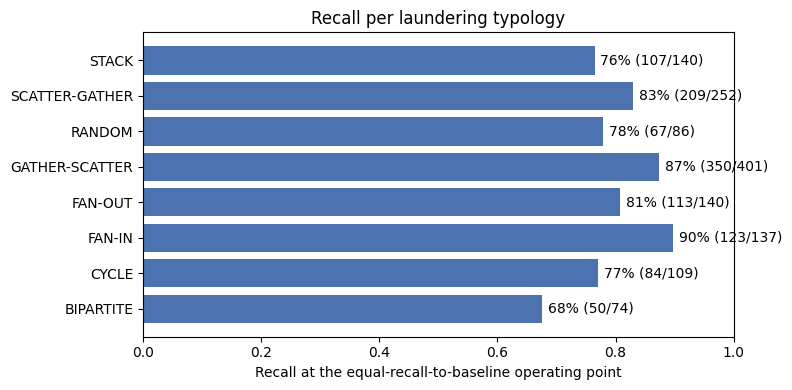

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(typology_table["typology"], typology_table["recall"], color="#4C72B0")
ax.set_xlabel("Recall at the equal-recall-to-baseline operating point")
ax.set_xlim(0, 1)
ax.set_title("Recall per laundering typology")
for i, row in typology_table.iterrows():
    ax.text(row["recall"] + 0.01, i, f"{row['recall']:.0%} ({row['n_caught']}/{row['n_transactions']})", va="center")
fig.tight_layout()
fig.savefig("../reports/figures/04_recall_per_typology.png", dpi=150)
plt.show()

No typology falls dramatically below the others — even patterns without a dedicated graph feature (`BIPARTITE`, `STACK`, `RANDOM`) are still caught at a similar rate to `FAN-IN`/`CYCLE`, which the graph features were purpose-built for. That's a reasonable outcome: the account/window velocity, structuring, and payment-format signals generalize across typologies to some extent, even where the graph motif features don't target a pattern by name.

## 5. PR-AUC, ROC-AUC, precision@k

In [7]:
test_pr_auc, test_roc_auc = pr_roc_auc(y_test, test_scores)
print(f"Test PR-AUC:  {test_pr_auc:.4f}  (vs. {y_test.mean():.4%} for a random ranking)")
print(f"Test ROC-AUC: {test_roc_auc:.4f}  (reference only -- see notebook 03's discussion of why)")
print()
for k in k_values:
    print(f"  precision@{k:<5}: {precision_at_k(y_test, test_scores, k):.2%}")

Test PR-AUC:  0.3967  (vs. 0.1769% for a random ranking)
Test ROC-AUC: 0.9828  (reference only -- see notebook 03's discussion of why)

  precision@100  : 92.00%


  precision@500  : 74.80%
  precision@1000 : 60.60%


  precision@5000 : 20.68%


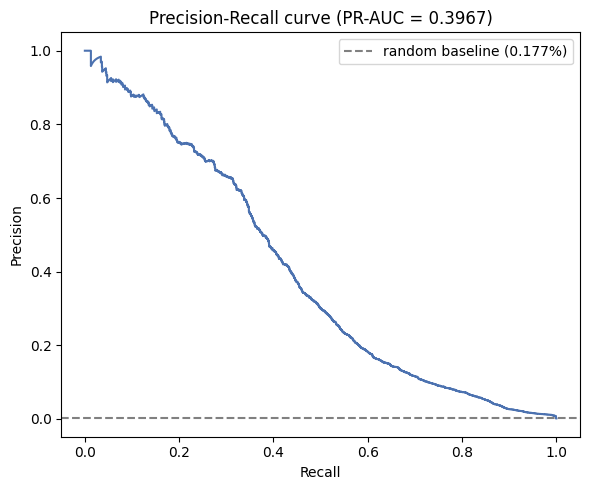

In [8]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, color="#4C72B0")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"random baseline ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve (PR-AUC = {test_pr_auc:.4f})")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/04_pr_curve.png", dpi=150)
plt.show()

## 6. Calibration — and an important caveat

Analysts triage by score, so scores should mean roughly what they claim to. Worth checking directly rather than assuming — `scale_pos_weight` (needed for the model to rank rare positives well at all) is well known to distort a model's raw probability output away from true calibration, and this dataset's numbers confirm it clearly.

In [9]:
print(f"Actual test-set prevalence: {y_test.mean():.4%}")
print(f"Mean predicted score:       {test_scores.mean():.4%}")
print(f"(mean predicted score is ~{test_scores.mean() / y_test.mean():.0f}x the true prevalence)")

calib = calibration_table(y_test, test_scores)
calib

Actual test-set prevalence: 0.1769%
Mean predicted score:       7.3141%
(mean predicted score is ~41x the true prevalence)


,mean_predicted_score,fraction_positive
0,0.002708,0.000000
1,0.003502,0.000010
2,0.004114,0.000000
3,0.004754,0.000010
4,0.005553,0.000000
5,0.006720,0.000000
6,0.008843,0.000000
7,0.015455,0.000059
8,0.147318,0.000876
9,0.532449,0.016738


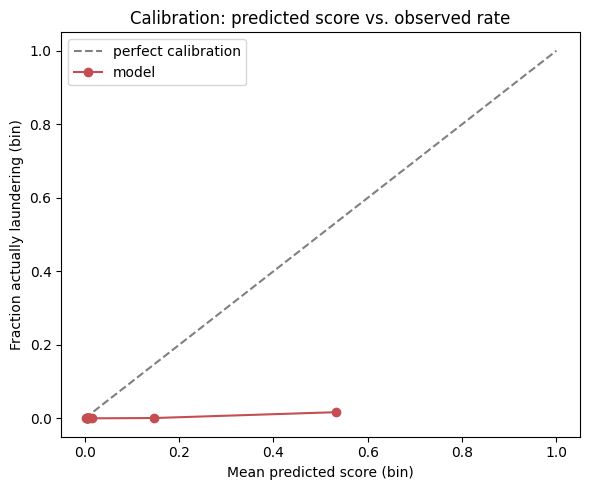

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect calibration")
ax.plot(calib["mean_predicted_score"], calib["fraction_positive"], marker="o", color="#C44E52", label="model")
ax.set_xlabel("Mean predicted score (bin)")
ax.set_ylabel("Fraction actually laundering (bin)")
ax.set_title("Calibration: predicted score vs. observed rate")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/04_calibration.png", dpi=150)
plt.show()

**Reading this:** the model's raw score is *not* a calibrated probability — a transaction scored ~0.53 is actually laundering only ~1.7% of the time, not 53% of the time. This is the expected, direct consequence of `scale_pos_weight=1324.94` (Phase 4): that weighting is exactly what lets the model rank rare positives above the enormous negative class at all, but it does so by inflating scores for anything resembling a positive, at the cost of the raw output no longer meaning "probability."

This does **not** undermine anything reported above: precision@k, recall-per-typology, and the headline false-positive-reduction number all depend only on the model's *ranking* (which transaction scores higher than which), not on the literal probability value — and ranking order is unaffected by this monotonic-ish inflation. It would matter if this project ever wanted to show an analyst a literal "73% chance of laundering" figure — for that, a post-hoc calibration step (Platt scaling or isotonic regression, fit on the validation split) would be needed. Noted as future work, not implemented here, to keep this phase's scope on what the brief actually asks for (a reliability *check*, not a calibrated-probability *product*).

## 7. Explainability (Phase 6) — SHAP reason codes

AML is a regulated domain: an analyst has to justify escalating a case, and an auditor has to be able to follow that justification afterwards. A ranked score with no attached reason is not reviewable, so the deliverable here is not SHAP plots but **a sentence per alert that a compliance analyst could paste into a case note**.

SHAP is computed over a bounded sample rather than all 1,015,669 test rows — all positives (at ~0.10% prevalence a uniform sample would contain almost none), plus the Phase 5 alert set, plus 20,000 background negatives that make mean |SHAP| a population statistic rather than an alerts-only one. See `src/explain.select_explanation_sample`.

In [11]:
feature_names = list(x_test.columns)

sample_idx = select_explanation_sample(y_test, model_alert_idx, 20_000, config["seed"])
x_sample = x_test.iloc[sample_idx]
shap_values = compute_shap_values(model, x_sample)

print(f"Explained {len(x_sample):,} rows ({int(y_test[sample_idx].sum())} positives)")

Explained 30,571 rows (1797 positives)


### 7.1 Faithfulness check

An explanation is only worth showing an analyst if it corresponds to what the model actually did. The guarantee is SHAP's additivity identity: `base_value + sum(contributions)` must reconstruct the model's raw margin output exactly.

The base value is **derived** here rather than read from `shap.TreeExplainer.expected_value`, which is unsafe for XGBoost — it reports `logit(base_score)` until the first `shap_values()` call and is then silently replaced by a different, correct value. See `reports/challenges.md`'s Phase 6 entry and `investigations/phase6_explainability/01_shap_expected_value_lazy_initialisation.py`.

In [12]:
base_value = shap_base_value(model, x_sample, shap_values)
margin = model.predict(x_sample, output_margin=True)
max_reconstruction_error = np.abs(base_value + shap_values.sum(axis=1) - margin).max()

print(f"Derived SHAP base value:        {base_value:.6f}")
print(f"max |base + sum(SHAP) - margin|: {max_reconstruction_error:.2e}")

Derived SHAP base value:        0.123039
max |base + sum(SHAP) - margin|: 4.77e-06


### 7.2 Global feature importance

Mean |SHAP| per feature, preferred over XGBoost's built-in gain/split-count importance (previewed in notebook 03) because it is in the same units and on the same scale as the per-alert explanations below — so the global story and the local story cannot disagree. `mean_shap` is reported alongside to separate "this feature matters and pushes toward laundering" from "this feature matters and pushes away from it"; it is negative for most features simply because the overwhelming majority of rows are legitimate.

In [13]:
importance = global_importance(shap_values, feature_names)
importance.head(15)

,feature,mean_abs_shap,mean_shap
0,payment_format_ACH,1.827905,0.077641
1,amount_paid_usd,0.555813,-0.239588
2,sender_out_7d_distinct_counterparties,0.414036,-0.304342
3,receiver_in_7d_distinct_counterparties,0.371369,-0.087027
4,sender_out_1d_distinct_counterparties,0.226123,-0.156502
5,sender_out_1d_count,0.209331,-0.160865
6,sender_out_7d_count,0.178633,-0.104026
7,receiver_in_7d_count,0.173769,-0.148695
8,receiver_in_1d_count,0.169070,0.002561
9,sender_out_7d_amount_usd,0.151842,-0.118090


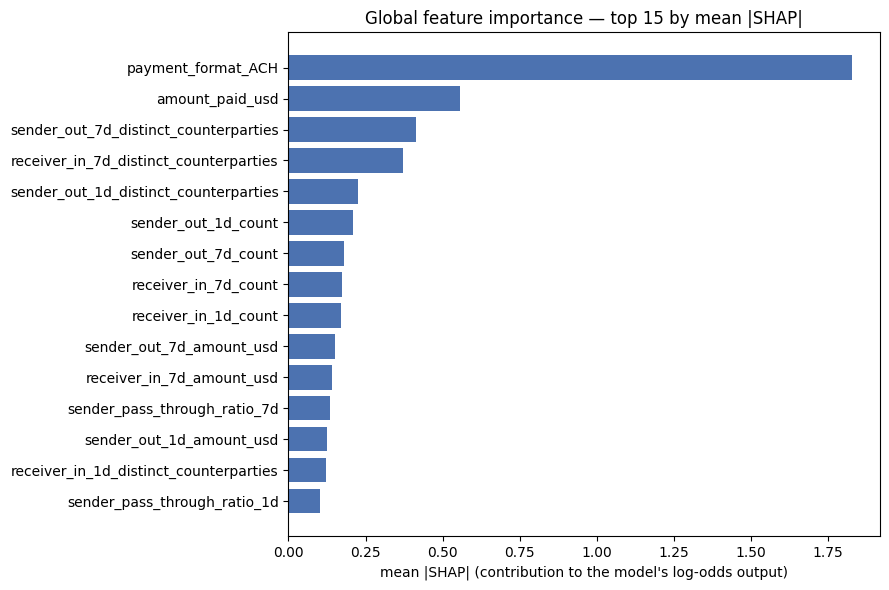

In [14]:
top_features = importance.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["feature"], top_features["mean_abs_shap"], color="#4C72B0")
ax.set_xlabel("mean |SHAP| (contribution to the model's log-odds output)")
ax.set_title("Global feature importance — top 15 by mean |SHAP|")
fig.tight_layout()
fig.savefig("../reports/figures/06_shap_global_importance.png", dpi=150)
plt.show()

### 7.3 Per-alert reason codes

Each reason code is composed from the top positive SHAP contributors, rendered against that row's **own raw feature values**. Two rules make it trustworthy:

- **Only features that pushed the score up are cited.** A negative SHAP value means the feature argued *against* the alert; listing it as a reason would be actively misleading in a case note.
- **Every clause states a checkable fact** about this specific transaction, so the sentence is generated from the model's reasoning rather than written to sound plausible.

Two variants are produced. The **faithful** variant reports exactly what SHAP ranks. The **behavioural** variant excludes the `payment_format_*` one-hots from the sentence only (never from the model) — section 7.4 shows why that matters.

In [15]:
sample_positions = {position: i for i, position in enumerate(sample_idx)}

spot_checks = []
for rank, position in enumerate(np.argsort(-test_scores)[:5], start=1):
    i = sample_positions[position]
    row = x_sample.iloc[i]
    spot_checks.append(
        {
            "rank": rank,
            "score": round(float(test_scores[position]), 4),
            "is_laundering": int(y_test[position]),
            "faithful": build_reason_code(shap_values[i], row, feature_names),
            "behavioural": build_reason_code(
                shap_values[i], row, feature_names,
                exclude_features=PAYMENT_FORMAT_FEATURES,
            ),
        }
    )

pd.set_option("display.max_colwidth", None)
pd.DataFrame(spot_checks)

,rank,score,is_laundering,faithful,behavioural
0,1,0.9952,1,"Flagged: the payment was made via ACH; the receiver received from 11 distinct counterparties in the past 7 days; a $18,756 payment.","Flagged: the receiver received from 11 distinct counterparties in the past 7 days; a $18,756 payment; the receiver received from 10 distinct accounts in the graph window."
1,2,0.9949,1,"Flagged: the payment was made via ACH; the receiver received from 11 distinct counterparties in the past 7 days; a $17,476 payment.","Flagged: the receiver received from 11 distinct counterparties in the past 7 days; a $17,476 payment; the receiver received from 10 distinct accounts in the graph window."
2,3,0.9948,1,"Flagged: the payment was made via ACH; the receiver received from 13 distinct counterparties in the past 7 days; a $9,356 payment.","Flagged: the receiver received from 13 distinct counterparties in the past 7 days; a $9,356 payment; the sender is structurally a collector (mostly receiving), fan-in score 1.00."
3,4,0.9948,1,"Flagged: the payment was made via ACH; the receiver received from 16 distinct counterparties in the past 7 days; a $18,515 payment.","Flagged: the receiver received from 16 distinct counterparties in the past 7 days; a $18,515 payment; the receiver received from 13 distinct accounts in the graph window."
4,5,0.9948,1,"Flagged: the payment was made via ACH; the receiver received from 9 distinct counterparties in the past 7 days; a $15,146 payment.","Flagged: the receiver received from 9 distinct counterparties in the past 7 days; a $15,146 payment; the receiver received from 8 distinct accounts in the graph window."


**PLAN.md's Phase 6 check** is to spot-check flagged alerts' reason codes against their raw feature values. Below is that check for the top-ranked alert: every cited feature, its actual value from the modelling table, its SHAP contribution, and the clause generated from it. `investigations/phase6_explainability/02_reason_code_spot_check_vs_raw_values.py` runs this for all five and *asserts* the grounding programmatically — it parses the number back out of each generated sentence and compares it to the raw value, which is what would catch a row-alignment or sender/receiver mix-up producing a fluent but false justification.

In [16]:
top_position = int(np.argsort(-test_scores)[0])
top_row = x_sample.iloc[sample_positions[top_position]]
top_shap = shap_values[sample_positions[top_position]]

pd.DataFrame(
    [
        {
            "feature": feature,
            "raw_value": float(top_row[feature]),
            "shap": round(shap_value, 4),
            "clause": describe_feature(feature, float(top_row[feature])),
        }
        for feature, shap_value in top_contributors(top_shap, feature_names, top_n=6)
    ]
)

,feature,raw_value,shap,clause
0,payment_format_ACH,1.000000,2.8762,the payment was made via ACH
1,receiver_in_7d_distinct_counterparties,11.000000,1.2523,the receiver received from 11 distinct counterparties in the past 7 days
2,amount_paid_usd,18755.939453,0.7748,"a $18,756 payment"
3,receiver_graph_in_degree,10.000000,0.2976,the receiver received from 10 distinct accounts in the graph window
4,sender_graph_fan_in_score,0.666667,0.1612,"the sender is structurally a collector (mostly receiving), fan-in score 0.67"
5,receiver_in_1d_distinct_counterparties,4.000000,0.1429,the receiver received from 4 distinct counterparties in the past 24h


### 7.4 The finding: a faithful reason code that leads with the same clause every time

Phase 4 established that `payment_format_ACH` dominates this model's importance because 86.6% of labelled laundering in HI-Small uses ACH. Section 7.2 confirms it under SHAP too. The Phase 6 question is what that does to the **explanation layer** specifically: if the same categorical is the top contributor on nearly every alert, the faithful reason code opens with an identical clause across the queue, and a constant lead cannot help an analyst decide which alert to open first.

Quantified below over the Phase 5 alert queue (the 10,011 alerts at the equal-recall-to-baseline operating point — the queue an analyst would actually be handed).

In [17]:
queue_indices = [sample_positions[position] for position in model_alert_idx]

faithful_leads, behavioural_leads = Counter(), Counter()
for i in queue_indices:
    faithful = top_contributors(shap_values[i], feature_names, top_n=1)
    behavioural = top_contributors(
        shap_values[i], feature_names, top_n=1, exclude_features=PAYMENT_FORMAT_FEATURES
    )
    faithful_leads[faithful[0][0] if faithful else "<none>"] += 1
    behavioural_leads[behavioural[0][0] if behavioural else "<none>"] += 1

n_queue = len(queue_indices)
ach_leads = faithful_leads["payment_format_ACH"]
print(
    f"payment_format_ACH leads the faithful reason code for "
    f"{ach_leads:,}/{n_queue:,} = {ach_leads / n_queue:.2%} of the alert queue\n"
)

pd.DataFrame(
    {
        "faithful": pd.Series(faithful_leads),
        "behavioural": pd.Series(behavioural_leads),
    }
).fillna(0).astype(int).sort_values("behavioural", ascending=False)

payment_format_ACH leads the faithful reason code for 9,997/10,011 = 99.86% of the alert queue



,faithful,behavioural
receiver_in_7d_distinct_counterparties,12,4106
amount_paid_usd,0,2786
sender_graph_fan_in_score,0,1553
receiver_in_1d_count,0,1250
sender_out_7d_count,0,151
receiver_in_7d_amount_usd,0,139
sender_out_7d_amount_usd,0,11
sender_out_1d_count,0,6
receiver_in_7d_count,0,4
sender_in_1d_amount_usd,0,4


**Reading this.** The faithful variant is honest about what the model uses, and it is not information-free overall — its second and third clauses still vary from alert to alert. But its *leading* clause is the same on ~99.9% of the queue, which is the part an analyst reads first. The behavioural variant drops the payment-format one-hots from the sentence only and surfaces the Phase 3 account/window and graph features instead — including `sender_graph_fan_in_score`, i.e. the network structure this project exists to exploit.

Both are reported rather than picking one, because they answer different questions: *what is the model actually doing* (faithful) versus *what should an analyst look at on this case* (behavioural). Exact figures are in `reports/results.md`'s Phase 6 section, and `investigations/phase6_explainability/03_ach_dominance_in_reason_codes.py` reproduces them.

## Next steps

Phase 7 (`src/monitoring.py`): PSI/CSI drift checks on the feature and score distributions across the dataset's time span. Phase 8 then precomputes the demo artifact — including a reason code per row via `build_reason_codes`, since the deployed app never runs SHAP live.